In [1]:
#-------- IMPORTING LIBRARIES --------#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier

In [2]:
#-------- DATA LOADING AND EXPLORATION --------#
# Load the dataset
data = pd.read_csv("training_data_M5_24.csv")
# Explore the dataset
print(data.head())
print(data.tail())
print(data.info())
print(data.describe())
print(data.shape)
# Check for missing values
print(data.isnull().sum())
print(data.columns)
print(data.describe(include='all'))
# Duplicate values
print(data.duplicated().sum())
# Data Types
print(data.dtypes)

  Flare            DATE__OBS  NOAA_AR  HARPNUM    USFLUX   TOTUSJH   TOTUSJZ  \
0     N  2023-01-03 18:36:00    13177     8923 -0.877771 -0.851649 -0.841043   
1     N  2023-01-03 18:48:00    13177     8923 -0.875756 -0.847173 -0.835644   
2     N  2023-01-03 19:00:00    13177     8923 -0.875219 -0.844854 -0.831772   
3     N  2023-01-03 19:12:00    13177     8923 -0.871942 -0.838273 -0.821357   
4     N  2023-01-03 19:24:00    13177     8923 -0.868639 -0.833376 -0.813119   

    MEANALP   R_VALUE    TOTPOT   SAVNCPP  AREA_ACR   ABSNJZH  
0 -0.445579  0.372630 -0.892655 -0.869557 -0.695751 -0.878711  
1 -0.446498  0.350569 -0.892883 -0.885357 -0.694607 -0.881184  
2 -0.449348  0.367115 -0.892317 -0.882771 -0.695381 -0.892749  
3 -0.449396  0.341262 -0.891861 -0.896272 -0.695834 -0.891898  
4 -0.446525  0.326784 -0.894040 -0.875498 -0.698612 -0.880152  
       Flare            DATE__OBS  NOAA_AR  HARPNUM    USFLUX   TOTUSJH  \
200837     N  2025-02-23 15:24:00    14000    12793 -0.91586

['N' 'padding' 'P']
Flare
N          123840
padding     65808
P           11194
Name: count, dtype: int64


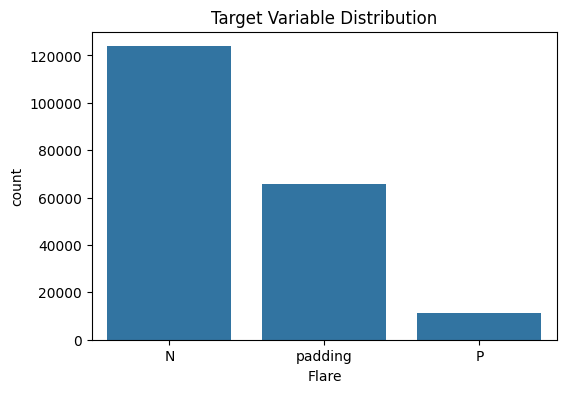

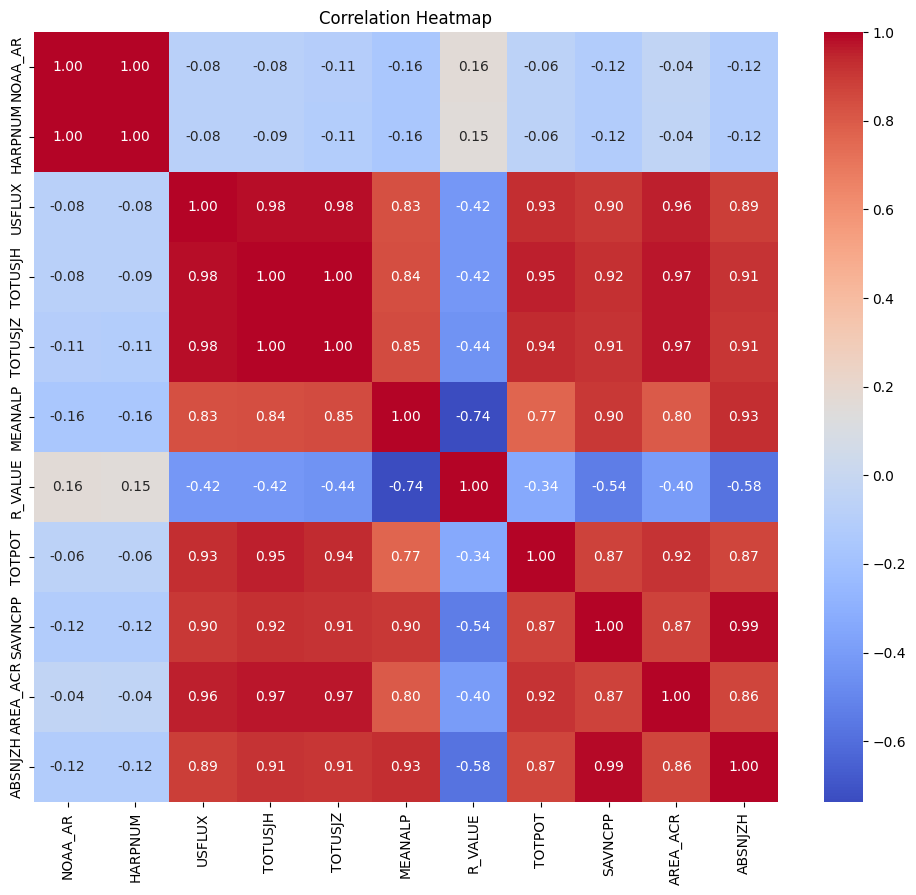

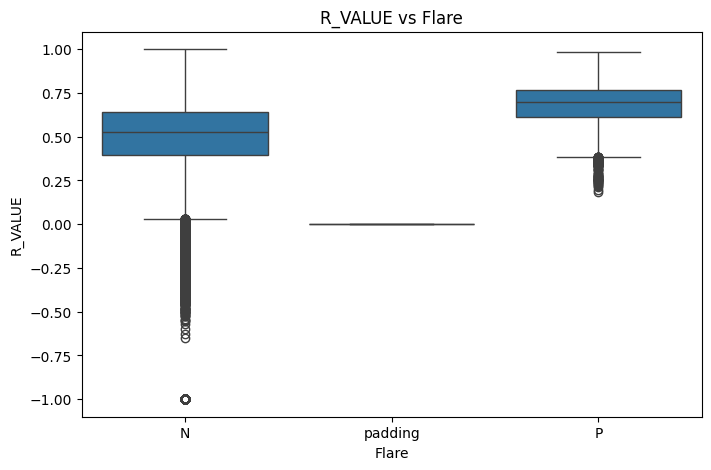

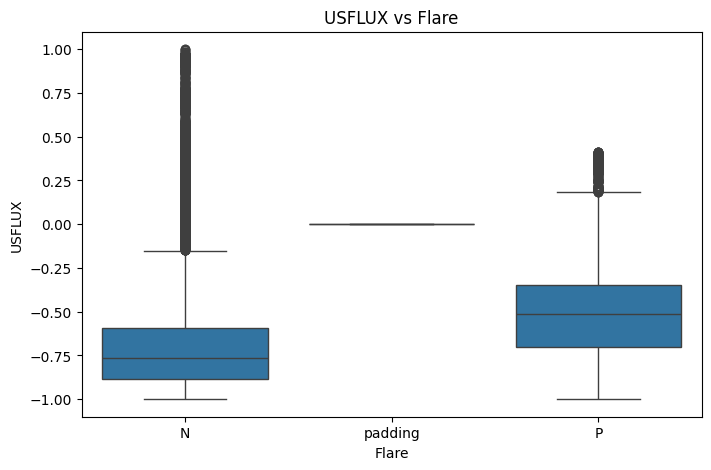

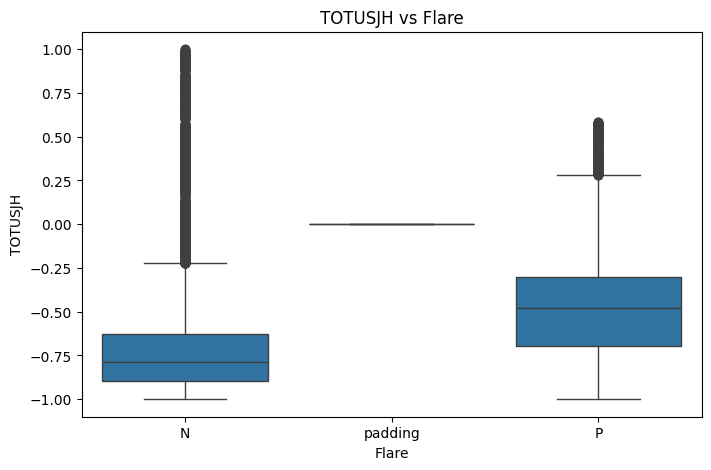

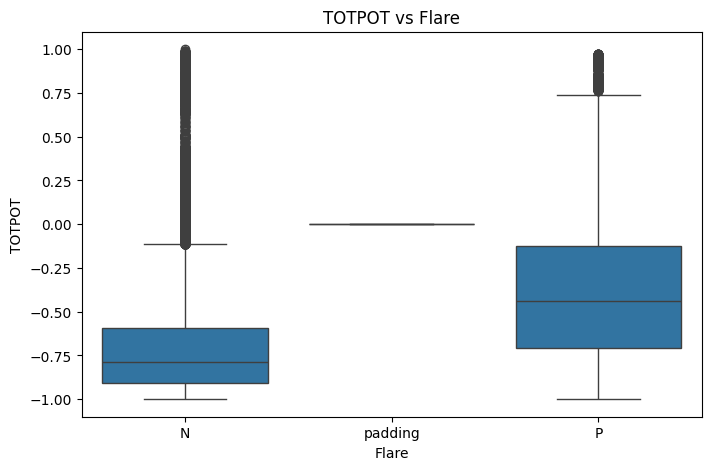

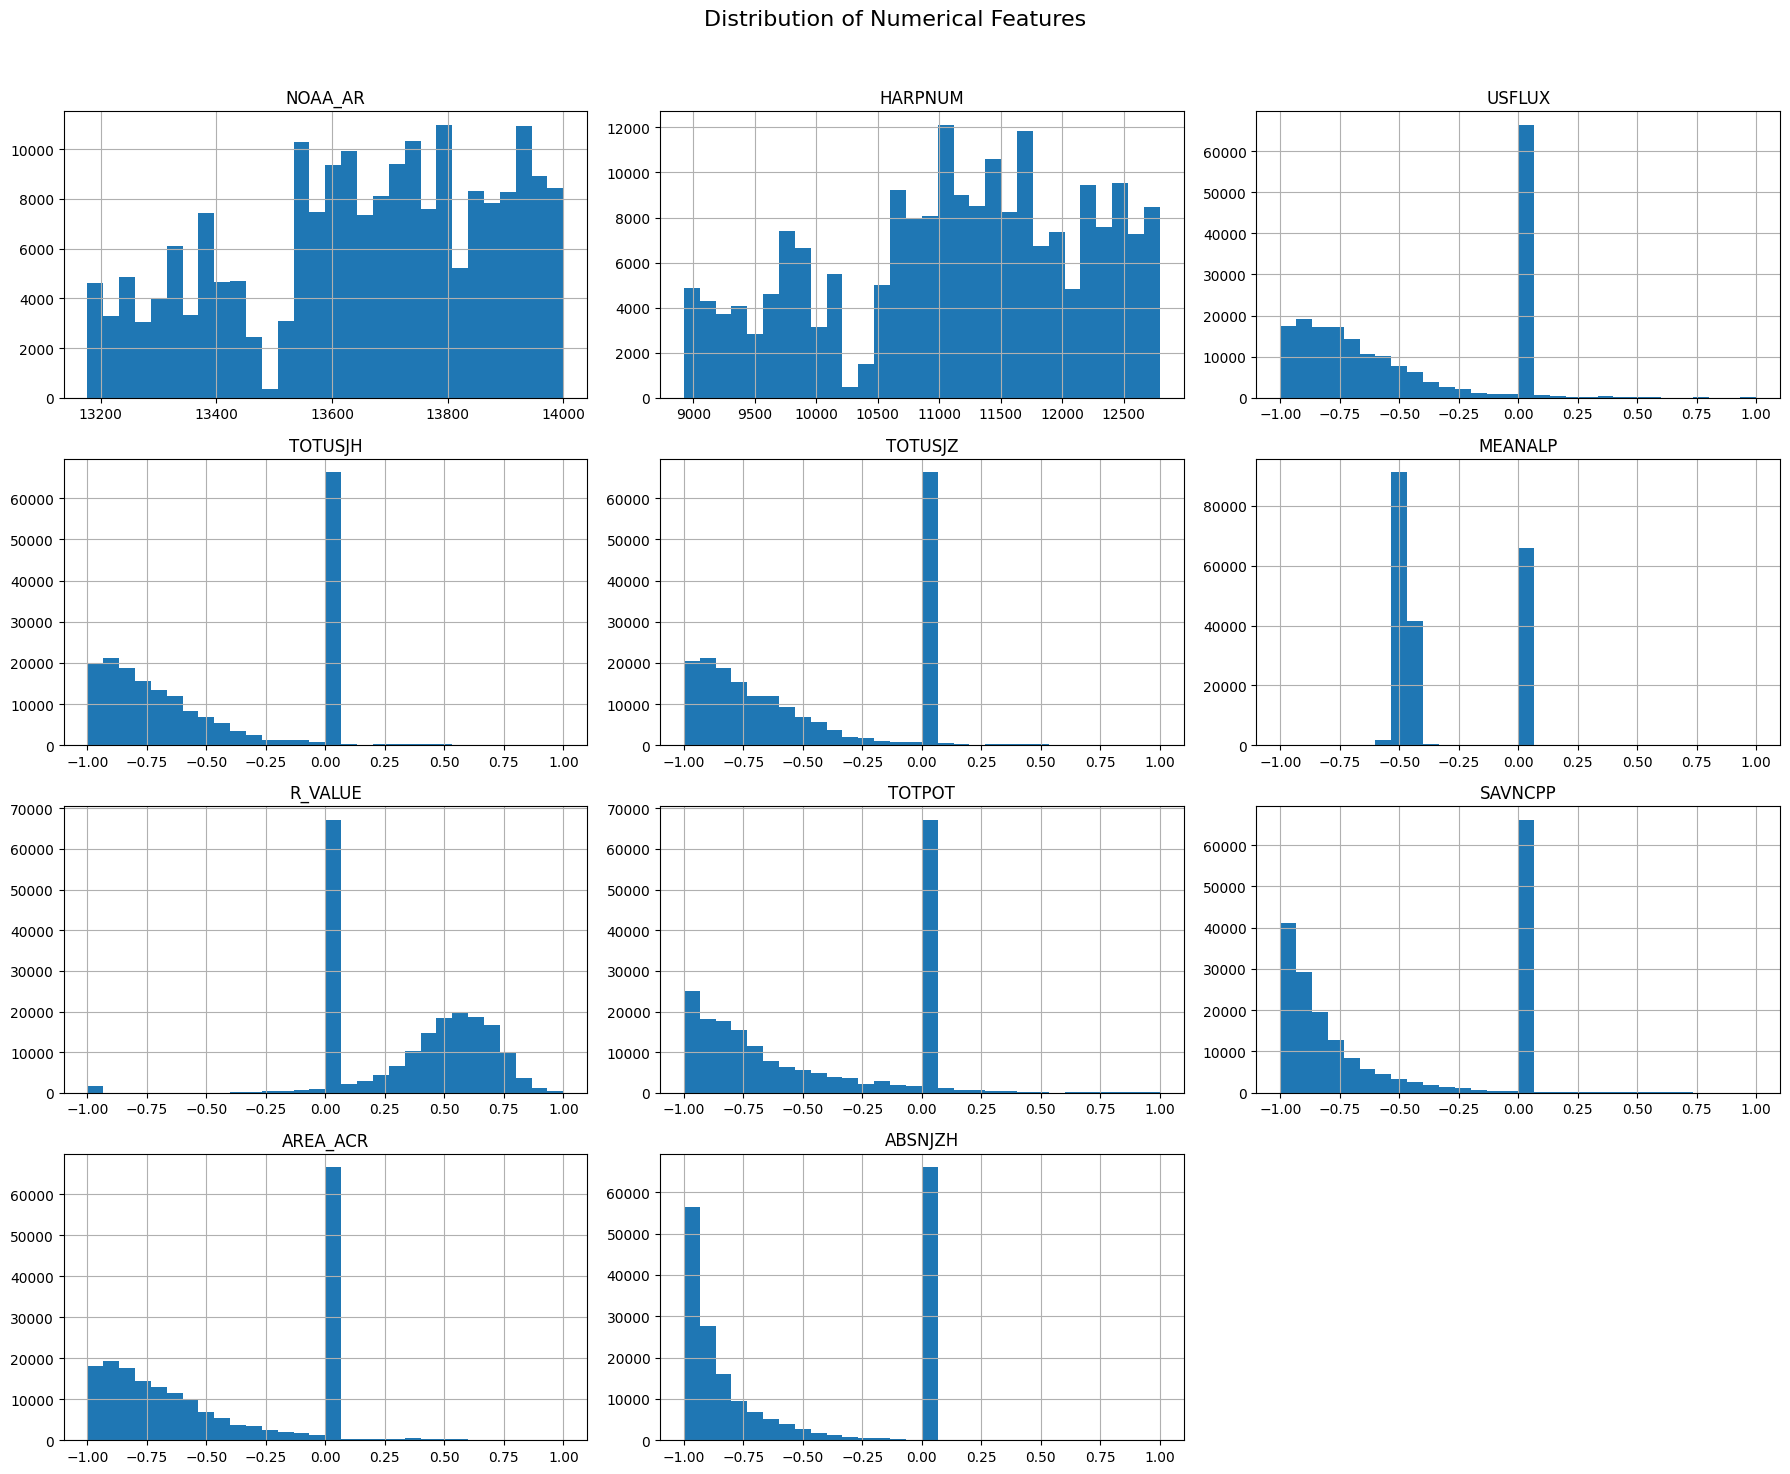

In [3]:
# Target
print(data["Flare"].unique())
print(data["Flare"].value_counts())
# Visualisation of Target
plt.figure(figsize=(6,4))
sns.countplot(x="Flare", data=data)

plt.title("Target Variable Distribution")
plt.show()

# Correlation
plt.figure(figsize=(12,10))

sns.heatmap(
    data.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Relation between Feature and Target
# 1. R_VALUE vs Flare
plt.figure(figsize=(8,5))
plt.title("R_VALUE vs Flare")
sns.boxplot(
    x="Flare",
    y="R_VALUE",
    data=data
)

plt.show()

# 2. USFLUX vs Flare
plt.figure(figsize=(8,5))
plt.title("USFLUX vs Flare")
sns.boxplot(
    x="Flare",
    y="USFLUX",
    data=data
)

plt.show()

# 3. TOTUSJH vs Flare
plt.figure(figsize=(8,5))
plt.title("TOTUSJH vs Flare")
sns.boxplot(
    x="Flare",
    y="TOTUSJH",
    data=data
)

plt.show()

# 4. TOTPOT vs Flare
plt.figure(figsize=(8,5))
plt.title("TOTPOT vs Flare")
sns.boxplot(
    x="Flare",
    y="TOTPOT",
    data=data
)

plt.show()

# Feature Distributions
data.hist(figsize=(18, 15), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [4]:
# Remove padding rows
data = data[data["Flare"] != "padding"]

# Convert target to binary
data["Flare"] = data["Flare"].map({
    "N": 0,
    "P": 1
})

# Verify the updated target
print(data["Flare"].value_counts())

# Drop non-predictive columns
data = data.drop(columns=["DATE__OBS", "NOAA_AR", "HARPNUM"])
print(data.head())

Flare
0    123840
1     11194
Name: count, dtype: int64
   Flare    USFLUX   TOTUSJH   TOTUSJZ   MEANALP   R_VALUE    TOTPOT  \
0      0 -0.877771 -0.851649 -0.841043 -0.445579  0.372630 -0.892655   
1      0 -0.875756 -0.847173 -0.835644 -0.446498  0.350569 -0.892883   
2      0 -0.875219 -0.844854 -0.831772 -0.449348  0.367115 -0.892317   
3      0 -0.871942 -0.838273 -0.821357 -0.449396  0.341262 -0.891861   
4      0 -0.868639 -0.833376 -0.813119 -0.446525  0.326784 -0.894040   

    SAVNCPP  AREA_ACR   ABSNJZH  
0 -0.869557 -0.695751 -0.878711  
1 -0.885357 -0.694607 -0.881184  
2 -0.882771 -0.695381 -0.892749  
3 -0.896272 -0.695834 -0.891898  
4 -0.875498 -0.698612 -0.880152  


Flare
0    123840
1     11194
Name: count, dtype: int64
Flare
0    91.710236
1     8.289764
Name: proportion, dtype: float64
Flare
0    99072
1     8955
Name: count, dtype: int64
Flare
1    99072
0    99072
Name: count, dtype: int64


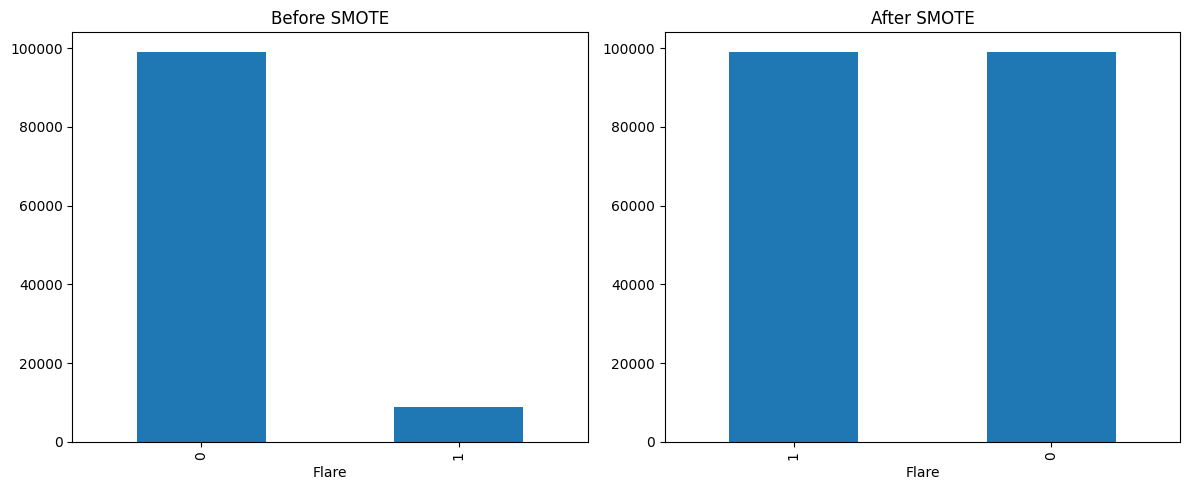

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [5]:
#-------- HANDLING CLASS IMBALANCE --------#
# Check class distribution
print(data["Flare"].value_counts())

print(data["Flare"].value_counts(normalize=True) * 100)

### OBSERVATION:

#The target variable is highly imbalanced.
#Approximately 91.71% of the samples belong to the non-flare class, while only 8.29% belong to the flare class.
#Such an imbalance can bias machine learning models toward the majority class.
#Therefore, a class balancing technique such as SMOTE will be applied to the training data before model training.

# Split the Data
X = data.drop(columns=["Flare"])
y = data["Flare"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(y_train.value_counts())
baseline_dt = DecisionTreeClassifier(random_state=42)

baseline_dt.fit(X_train, y_train)



smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print(y_train_smote.value_counts())

# Before SMOTE vs After SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))

y_train.value_counts().plot(kind="bar", ax=axes[0], title="Before SMOTE")
y_train_smote.value_counts().plot(kind="bar", ax=axes[1], title="After SMOTE")

plt.tight_layout()
plt.show()

# Strategy 2: Class Weight
balanced_dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

balanced_dt.fit(X_train, y_train)

In [6]:
#---- CROSS VALIDATION ----#
# Cross-validation is a technique used to assess the performance of a machine learning model by splitting the
# dataset into multiple subsets (folds) and training/testing the model on different combinations of these folds.
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}
# BASELINE MODEL: Decision Tree Classifier
baseline_scores = cross_validate(
    baseline_dt,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)
# SMOTE
smote_scores = cross_validate(
    DecisionTreeClassifier(random_state=42),
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring=scoring
)
# CLASS WEIGHTS
balanced_scores = cross_validate(
    balanced_dt,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)
 # COMPARISON OF CROSS-VALIDATION RESULTS
comparison = pd.DataFrame({
    "Model": ["Baseline", "SMOTE", "Class Weight"],
    "Accuracy": [
        baseline_scores["test_accuracy"].mean(),
        smote_scores["test_accuracy"].mean(),
        balanced_scores["test_accuracy"].mean()
    ],
    "Precision": [
        baseline_scores["test_precision"].mean(),
        smote_scores["test_precision"].mean(),
        balanced_scores["test_precision"].mean()
    ],
    "Recall": [
        baseline_scores["test_recall"].mean(),
        smote_scores["test_recall"].mean(),
        balanced_scores["test_recall"].mean()
    ],
    "F1 Score": [
        baseline_scores["test_f1"].mean(),
        smote_scores["test_f1"].mean(),
        balanced_scores["test_f1"].mean()
    ],
    "ROC-AUC": [
        baseline_scores["test_roc_auc"].mean(),
        smote_scores["test_roc_auc"].mean(),
        balanced_scores["test_roc_auc"].mean()
    ]
})

print(comparison)


          Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0      Baseline  0.981357   0.896847  0.875935  0.886245  0.933410
1         SMOTE  0.989397   0.987033  0.991824  0.989421  0.989397
2  Class Weight  0.981912   0.902906  0.876047  0.889252  0.933764


In [7]:
#-------- FEATURE ENGINEERING --------#
# Feature engineering is the process of creating new, meaningful input features
# from existing data to improve the performance of machine learning models.

print((data["AREA_ACR"] == 0).sum()) # Check how many rows have AREA_ACR as 0


#  1.MAGNETIC FLUX DENSITY
X_train_smote["MAGNETIC_FLUX_DENSITY"] = X_train_smote["USFLUX"] / X_train_smote["AREA_ACR"]

# 2. CURRENT HELICITY DENSITY
X_train_smote["CURRENT_HELICITY_DENSITY"] = X_train_smote["TOTUSJH"] / X_train_smote["AREA_ACR"]

# 3. CURRENT DENSITY
X_train_smote["CURRENT_DENSITY"] = X_train_smote["TOTUSJZ"] / X_train_smote["AREA_ACR"]

# 4. FREE ENERGY DENSITY
X_train_smote["FREE_ENERGY_DENSITY"] = X_train_smote["TOTPOT"] / X_train_smote["AREA_ACR"]

# 5. Twist Energy Index
X_train_smote["Twist_Energy_Index"] = (
    X_train_smote["MEANALP"] * X_train_smote["TOTPOT"]
)

# Verification of new features
print(X_train_smote.head())
print(X_train_smote.columns)

#--- Feature Engineering Summary--#

#Five additional features were created to enhance the predictive capability of the machine learning models.

# Flux_Density = USFLUX / AREA_ACR
# 1. Helicity_Density = TOTUSJH / AREA_ACR
# 2. Current_Density = TOTUSJZ / AREA_ACR
# 3. Energy_Density = TOTPOT / AREA_ACR
# 4. Twist_Energy_Index = MEANALP × TOTPOT

#These engineered features represent normalized magnetic properties and interactions
# between existing magnetic parameters, providing additional information
# that may help distinguish flare-producing active regions from non-flaring regions.



0
     USFLUX   TOTUSJH   TOTUSJZ   MEANALP   R_VALUE    TOTPOT   SAVNCPP  \
0 -0.410873 -0.368949 -0.412966 -0.490573  0.702861 -0.379702 -0.736045   
1 -0.868329 -0.908097 -0.912092 -0.459948  0.603585 -0.912589 -0.967280   
2 -0.330007 -0.074778 -0.245697 -0.448202  0.772492  0.115478 -0.245408   
3 -0.049049 -0.107179 -0.043020 -0.469526  0.749052 -0.306825 -0.653841   
4 -0.778362 -0.857790 -0.837162 -0.480770  0.360221 -0.923690 -0.953895   

   AREA_ACR   ABSNJZH  MAGNETIC_FLUX_DENSITY  CURRENT_HELICITY_DENSITY  \
0 -0.167570 -0.717524               2.451944                  2.201759   
1 -0.921430 -0.936975               0.942371                  0.985531   
2  0.064907 -0.243449              -5.084348                 -1.152081   
3 -0.137202 -0.800802               0.357494                  0.781175   
4 -0.873486 -0.978139               0.891098                  0.982030   

   CURRENT_DENSITY  FREE_ENERGY_DENSITY  Twist_Energy_Index  
0         2.464436             2.265929 

In [8]:
# ----- MODELING AND EVALUATION ------- #
# The modeling and evaluation phase involves training machine learning models on the processed dataset and assessing
#  their performance using various metrics.
#  The goal is to identify the best-performing model for predicting solar flares based on the features in the dataset.

# --- CREATE MODELS AND CROSS VALIDATE --- #
# 1. Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

dt_scores = cross_validate(
    dt_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("Decision Tree")
print("Accuracy :", dt_scores["test_accuracy"].mean())
print("Precision:", dt_scores["test_precision"].mean())
print("Recall   :", dt_scores["test_recall"].mean())
print("F1 Score :", dt_scores["test_f1"].mean())
print("ROC-AUC  :", dt_scores["test_roc_auc"].mean())

Decision Tree
Accuracy : 0.9910418713409408
Precision: 0.9888269313401621
Recall   : 0.9933079440461701
F1 Score : 0.9910598408416119
ROC-AUC  : 0.9910418950236697


In [10]:
# 2. Random Forest Classifier
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)

rf_scores = cross_validate(
    rf_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("Random Forest")
print("Accuracy :", rf_scores["test_accuracy"].mean())
print("Precision:", rf_scores["test_precision"].mean())
print("Recall   :", rf_scores["test_recall"].mean())
print("F1 Score :", rf_scores["test_f1"].mean())
print("ROC-AUC  :", rf_scores["test_roc_auc"].mean())

Random Forest
Accuracy : 0.9979307976760522
Precision: 0.9968177729393416
Recall   : 0.999051194784216
F1 Score : 0.9979331632089901
ROC-AUC  : 0.9999535037133045


In [11]:
# 3. AdaBoost Classifier
ada_model = AdaBoostClassifier(
    random_state=42
)

ada_scores = cross_validate(
    ada_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("AdaBoost")
print("Accuracy :", ada_scores["test_accuracy"].mean())
print("Precision:", ada_scores["test_precision"].mean())
print("Recall   :", ada_scores["test_recall"].mean())
print("F1 Score :", ada_scores["test_f1"].mean())
print("ROC-AUC  :", ada_scores["test_roc_auc"].mean())

AdaBoost
Accuracy : 0.7472393808738358
Precision: 0.7500868142216361
Recall   : 0.7415919410599321
F1 Score : 0.7457949067526878
ROC-AUC  : 0.8285567230928412


In [14]:
# 4. Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_scores = cross_validate(
    gb_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("Gradient Boosting")
print("Accuracy :", gb_scores["test_accuracy"].mean())
print("Precision:", gb_scores["test_precision"].mean())
print("Recall   :", gb_scores["test_recall"].mean())
print("F1 Score :", gb_scores["test_f1"].mean())
print("ROC-AUC  :", gb_scores["test_roc_auc"].mean())


Gradient Boosting
Accuracy : 0.8642452140952648
Precision: 0.8438816061440448
Recall   : 0.8938551058276236
F1 Score : 0.8681413469796233
ROC-AUC  : 0.9361084968345157


In [15]:
# 5. XGBoost Classifier
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_scores = cross_validate(
    xgb_model,
    X_train_smote,
    y_train_smote,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("XGBoost")
print("Accuracy :", xgb_scores["test_accuracy"].mean())
print("Precision:", xgb_scores["test_precision"].mean())
print("Recall   :", xgb_scores["test_recall"].mean())
print("F1 Score :", xgb_scores["test_f1"].mean())
print("ROC-AUC  :", xgb_scores["test_roc_auc"].mean())


XGBoost
Accuracy : 0.9919704876640196
Precision: 0.9866136842836815
Recall   : 0.9974765867610411
F1 Score : 0.9920147321858457
ROC-AUC  : 0.9994234173153089


In [16]:
#------- HYPERPARAMETER TUNING -------#
# Hyperparameter tuning is the process of optimizing the parameters of a machine learning model to improve its performance.
# We will use GridSearchCV to find the best hyperparameters for Decision Trees, Random Forest and Adaboost.
# We will use RandomizedsearchCV to find the Best hyperparameters for Gardient Boosting and XGBoost

# 1. Decision Tree Classifier
dt_param_grid = {
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
dt_grid_search.fit(X_train_smote, y_train_smote)

print("Best parameters for Decision Tree:")
print(dt_grid_search.best_params_)
print("Best cross-validation score for Decision Tree:")
print(dt_grid_search.best_score_)

Best parameters for Decision Tree:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation score for Decision Tree:
0.9910598408416119


In [17]:
# 2. Random Forest Classifier
rf_param_grid = {
    "n_estimators": [100],
    "max_depth": [10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1]
}

rf_grid_search = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
         n_jobs=-1
    ),
    rf_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)
rf_grid_search.fit(X_train_smote, y_train_smote)

print("Best parameters for Random Forest:")
print(rf_grid_search.best_params_)
print("Best cross-validation score for Random Forest:")
print(rf_grid_search.best_score_)

Best parameters for Random Forest:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score for Random Forest:
0.9512816280838586


In [18]:
# 3. AdaBoost Classifier
ada_param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1]
}

ada_grid_search = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)
ada_grid_search.fit(X_train_smote, y_train_smote)

print("Best parameters for AdaBoost:")
print(ada_grid_search.best_params_)
print("Best cross-validation score for AdaBoost:")
print(ada_grid_search.best_score_)


Best parameters for AdaBoost:
{'learning_rate': 0.1, 'n_estimators': 100}
Best cross-validation score for AdaBoost:
0.750026941833692


In [22]:
# 4. Gradient Boosting Classifier
gb_param_dist = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1],
    "max_depth": [2, 3]
}

gb_random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=8,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

gb_random_search.fit(X_train_smote, y_train_smote)

print("Best parameters for Gradient Boosting:")
print(gb_random_search.best_params_)
print("Best cross-validation score for Gradient Boosting:")
print(gb_random_search.best_score_)


Best parameters for Gradient Boosting:
{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Best cross-validation score for Gradient Boosting:
0.8673832220834542


In [23]:
# 5. XGBoost Classifier
xgb_param_dist = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1],
    "max_depth": [2, 3,],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_dist,
    n_iter=8,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train_smote, y_train_smote)

print("Best parameters for XGBoost:")
print(xgb_random_search.best_params_)
print("Best cross-validation score for XGBoost:")
print(xgb_random_search.best_score_)

Best parameters for XGBoost:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best cross-validation score for XGBoost:
0.8643045892558533


In [24]:
# --- SAVE THE BEST MODEL --- #

best_dt_model = dt_grid_search.best_estimator_
best_rf_model = rf_grid_search.best_estimator_
best_ada_model = ada_grid_search.best_estimator_
best_gb_model = gb_random_search.best_estimator_
best_xgb_model = xgb_random_search.best_estimator_


#-- EVALUATE THE BEST MODEL --#

# 1. Decision Tree Classifier
dt_score = cross_validate(
    best_dt_model,
    X_train_smote,
    y_train_smote,
    cv=3,
    scoring=scoring,
    n_jobs=-1
)

# 2. Random Forest Classifier
rf_score = cross_validate(
    best_rf_model,
    X_train_smote,
    y_train_smote,
    cv=3,
    scoring=scoring,
    n_jobs=-1
)

#3. AdaBoost Classifier
ada_score = cross_validate(
    best_ada_model,
    X_train_smote,
    y_train_smote,
    cv=3,
    scoring=scoring,
    n_jobs=-1
)

# 4. Gradient Boosting Classifier
gb_score = cross_validate(
    best_gb_model,
    X_train_smote,
    y_train_smote,
    cv=3,
    scoring=scoring,
    n_jobs=-1
)

# 5. XGBoost Classifier
xgb_score = cross_validate(
    best_xgb_model,
    X_train_smote,
    y_train_smote,
    cv=3,
    scoring=scoring,
    n_jobs=-1
)

#------- COMPARISON TABLE -------#
comparison_final = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "AdaBoost", "Gradient Boosting", "XGBoost"],
    "Accuracy": [
        dt_score["test_accuracy"].mean(),
        rf_score["test_accuracy"].mean(),
        ada_score["test_accuracy"].mean(),
        gb_score["test_accuracy"].mean(),
        xgb_score["test_accuracy"].mean()
    ],
    "Precision": [
        dt_score["test_precision"].mean(),
        rf_score["test_precision"].mean(),
        ada_score["test_precision"].mean(),
        gb_score["test_precision"].mean(),
        xgb_score["test_precision"].mean()
    ],
    "Recall": [
        dt_score["test_recall"].mean(),
        rf_score["test_recall"].mean(),
        ada_score["test_recall"].mean(),
        gb_score["test_recall"].mean(),
        xgb_score["test_recall"].mean()
    ],
    "F1 Score": [
        dt_score["test_f1"].mean(),
        rf_score["test_f1"].mean(),
        ada_score["test_f1"].mean(),
        gb_score["test_f1"].mean(),
        xgb_score["test_f1"].mean()
    ],
    "ROC-AUC": [
        dt_score["test_roc_auc"].mean(),
        rf_score["test_roc_auc"].mean(),
        ada_score["test_roc_auc"].mean(),
        gb_score["test_roc_auc"].mean(),
        xgb_score["test_roc_auc"].mean()
    ]
})

# Let's do comparison by F1 score
comparison_final = comparison_final.sort_values(by="F1 Score", ascending=False)
print(comparison_final)


               Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0      Decision Tree  0.989659   0.987175  0.992208  0.989684  0.989659
1      Random Forest  0.950031   0.927987  0.975785  0.951282  0.990789
3  Gradient Boosting  0.863236   0.841860  0.894511  0.867383  0.934954
4            XGBoost  0.859577   0.836144  0.894440  0.864305  0.933321
2           AdaBoost  0.740184   0.722692  0.779554  0.750027  0.818146


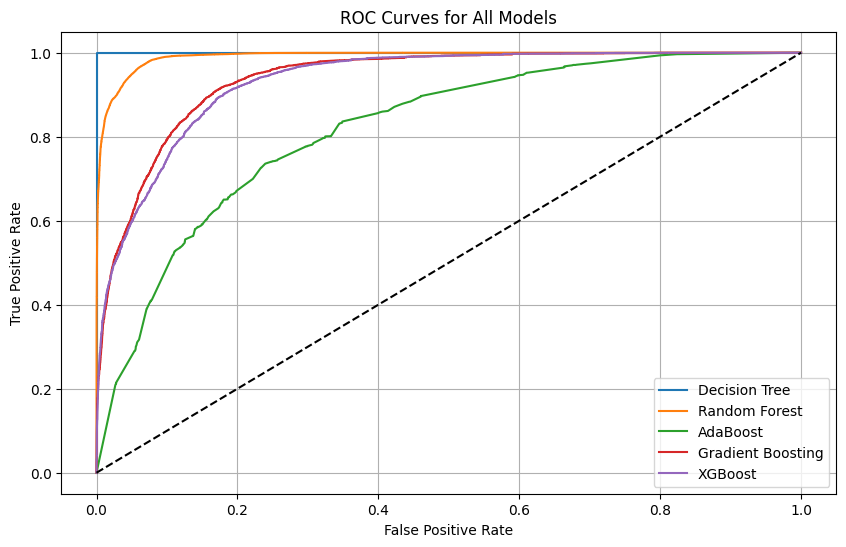

In [25]:
# ------ TRAIN THE BEST MODEL ON TRAINING DATA  ---- #
best_dt_model.fit(X_train_smote, y_train_smote)
best_rf_model.fit(X_train_smote, y_train_smote)
best_ada_model.fit(X_train_smote, y_train_smote)
best_gb_model.fit(X_train_smote, y_train_smote)
best_xgb_model.fit(X_train_smote, y_train_smote)

# Predictions

dt_prob = best_dt_model.predict_proba(X_train_smote)[:, 1]
rf_prob = best_rf_model.predict_proba(X_train_smote)[:, 1]
ada_prob = best_ada_model.predict_proba(X_train_smote)[:, 1]
gb_prob = best_gb_model.predict_proba(X_train_smote)[:, 1]
xgb_prob = best_xgb_model.predict_proba(X_train_smote)[:, 1]

# ---- ROC Curve calculation ---- #


dt_fpr, dt_tpr, _ = roc_curve(y_train_smote, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_train_smote, rf_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_train_smote, ada_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_train_smote, gb_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_train_smote, xgb_prob)

# Plot the ROC curves for all models
plt.figure(figsize=(10, 6))
plt.plot(dt_fpr, dt_tpr, label="Decision Tree")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(ada_fpr, ada_tpr, label="AdaBoost")
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
#------------ LOADING TESTING DATA ------------#
# Load the testing dataset
test_data = pd.read_csv("testing_data_M5_24.csv")

# Remove padding rows
test_data = test_data[test_data["Flare"] != "padding"]

# Convert target to binary
test_data["Flare"] = test_data["Flare"].map({
    "N": 0,
    "P": 1
})

test_data = test_data.drop(columns=["DATE__OBS", "NOAA_AR", "HARPNUM"])

#----- FEATURE ENGINEERING ON TEST DATA -----#
# 1. MAGNETIC FLUX DENSITY
test_data["MAGNETIC_FLUX_DENSITY"] = test_data["USFLUX"] / test_data["AREA_ACR"]

# 2. CURRENT HELICITY DENSITY
test_data["CURRENT_HELICITY_DENSITY"] = test_data["TOTUSJH"] / test_data["AREA_ACR"]

# 3. CURRENT DENSITY
test_data["CURRENT_DENSITY"] = test_data["TOTUSJZ"] / test_data["AREA_ACR"]

# 4. FREE ENERGY DENSITY
test_data["FREE_ENERGY_DENSITY"] = test_data["TOTPOT"] / test_data["AREA_ACR"]

# 5. Twist Energy Index
test_data["Twist_Energy_Index"] = (
    test_data["MEANALP"] * test_data["TOTPOT"]
)

X_test_final = test_data.drop(columns=["Flare"])
y_test_final = test_data["Flare"]


Final Model Performance on Testing Dataset
Accuracy: 0.9446
Precision: 0.0033
Recall: 0.0087
F1-Score: 0.0048
ROC-AUC: 0.4840

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     14773
           1       0.00      0.01      0.00       231

    accuracy                           0.94     15004
   macro avg       0.49      0.48      0.49     15004
weighted avg       0.97      0.94      0.96     15004



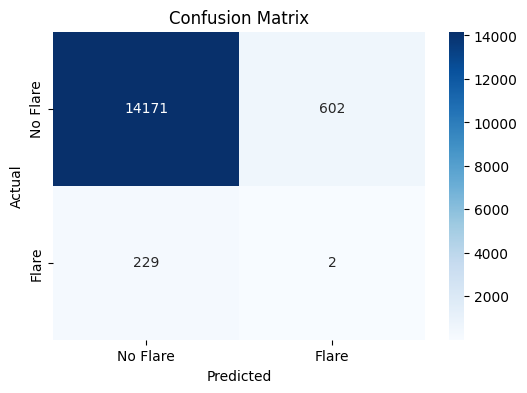

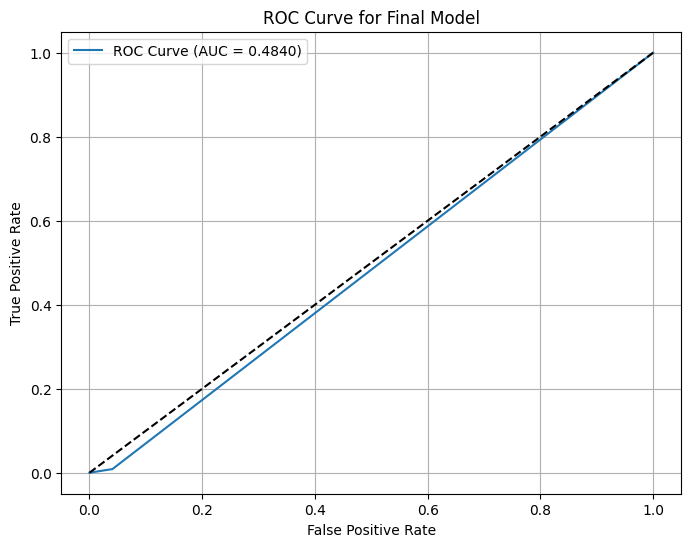

In [30]:

best_model = best_dt_model

# prediction
y_pred = best_model.predict(X_test_final)
y_prob = best_model.predict_proba(X_test_final)[:, 1]

# Evaluation metrics
print("Final Model Performance on Testing Dataset")


accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)
roc_auc = roc_auc_score(y_test_final, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ------ CLASSIFICATION REPORT AND CONFUSION MATRIX ------ #
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred))

cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Flare", "Flare"], yticklabels=["No Flare", "Flare"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC Curve for the final model
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Final Model")
plt.legend()
plt.grid(True)
plt.show()

Final Model Performance on Testing Dataset
Accuracy: 0.9609
Precision: 0.0215
Recall: 0.0346
F1-Score: 0.0265
ROC-AUC: 0.6761

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     14773
           1       0.02      0.03      0.03       231

    accuracy                           0.96     15004
   macro avg       0.50      0.50      0.50     15004
weighted avg       0.97      0.96      0.97     15004



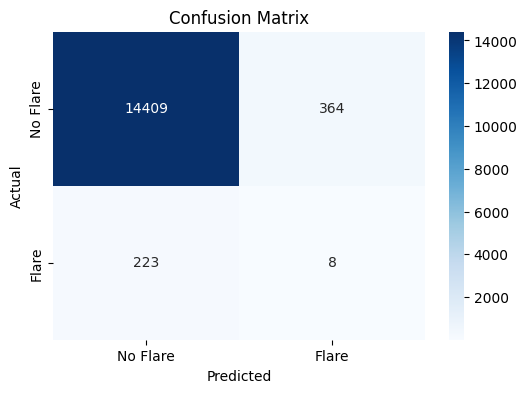

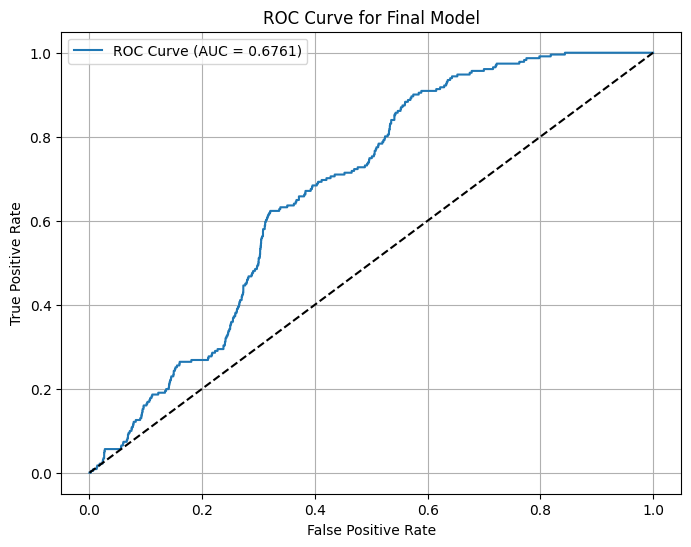

In [31]:

best_model = best_rf_model

# prediction
y_pred = best_model.predict(X_test_final)
y_prob = best_model.predict_proba(X_test_final)[:, 1]

# Evaluation metrics
print("Final Model Performance on Testing Dataset")


accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)
roc_auc = roc_auc_score(y_test_final, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ------ CLASSIFICATION REPORT AND CONFUSION MATRIX ------ #
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred))

cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Flare", "Flare"], yticklabels=["No Flare", "Flare"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC Curve for the final model
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Final Model")
plt.legend()
plt.grid(True)
plt.show()

Final Model Performance on Testing Dataset
Accuracy: 0.9108
Precision: 0.0115
Recall: 0.0563
F1-Score: 0.0190
ROC-AUC: 0.6645

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     14773
           1       0.01      0.06      0.02       231

    accuracy                           0.91     15004
   macro avg       0.50      0.49      0.49     15004
weighted avg       0.97      0.91      0.94     15004



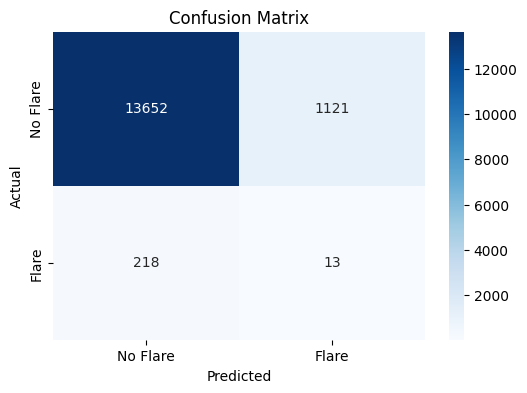

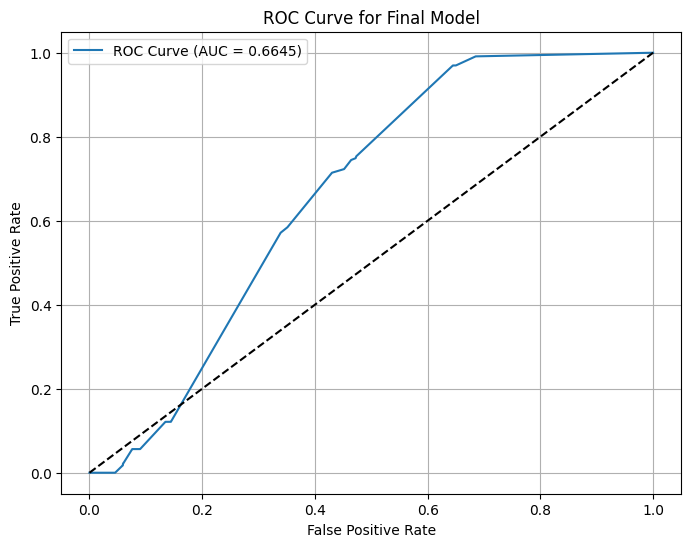

In [32]:

best_model = best_ada_model

# prediction
y_pred = best_model.predict(X_test_final)
y_prob = best_model.predict_proba(X_test_final)[:, 1]

# Evaluation metrics
print("Final Model Performance on Testing Dataset")


accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)
roc_auc = roc_auc_score(y_test_final, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ------ CLASSIFICATION REPORT AND CONFUSION MATRIX ------ #
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred))

cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Flare", "Flare"], yticklabels=["No Flare", "Flare"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC Curve for the final model
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Final Model")
plt.legend()
plt.grid(True)
plt.show()

Final Model Performance on Testing Dataset
Accuracy: 0.9320
Precision: 0.0183
Recall: 0.0649
F1-Score: 0.0285
ROC-AUC: 0.7167

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     14773
           1       0.02      0.06      0.03       231

    accuracy                           0.93     15004
   macro avg       0.50      0.51      0.50     15004
weighted avg       0.97      0.93      0.95     15004



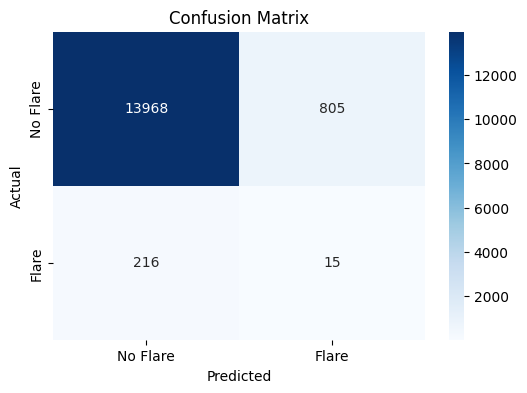

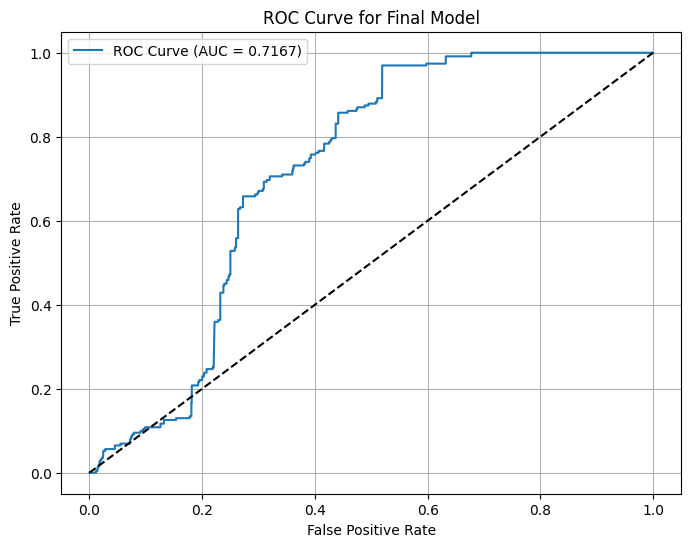

In [33]:

best_model = best_gb_model

# prediction
y_pred = best_model.predict(X_test_final)
y_prob = best_model.predict_proba(X_test_final)[:, 1]

# Evaluation metrics
print("Final Model Performance on Testing Dataset")


accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)
roc_auc = roc_auc_score(y_test_final, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ------ CLASSIFICATION REPORT AND CONFUSION MATRIX ------ #
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred))

cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Flare", "Flare"], yticklabels=["No Flare", "Flare"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC Curve for the final model
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Final Model")
plt.legend()
plt.grid(True)
plt.show()

Final Model Performance on Testing Dataset
Accuracy: 0.9278
Precision: 0.0181
Recall: 0.0693
F1-Score: 0.0287
ROC-AUC: 0.6615

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     14773
           1       0.02      0.07      0.03       231

    accuracy                           0.93     15004
   macro avg       0.50      0.51      0.50     15004
weighted avg       0.97      0.93      0.95     15004



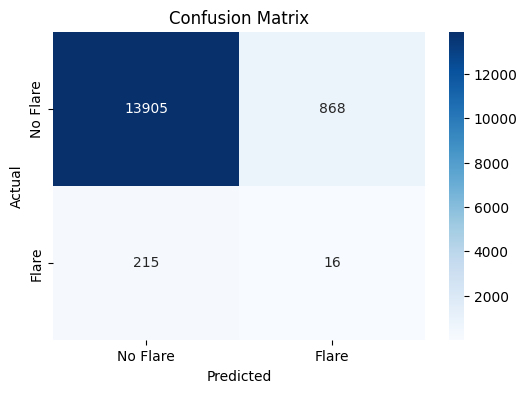

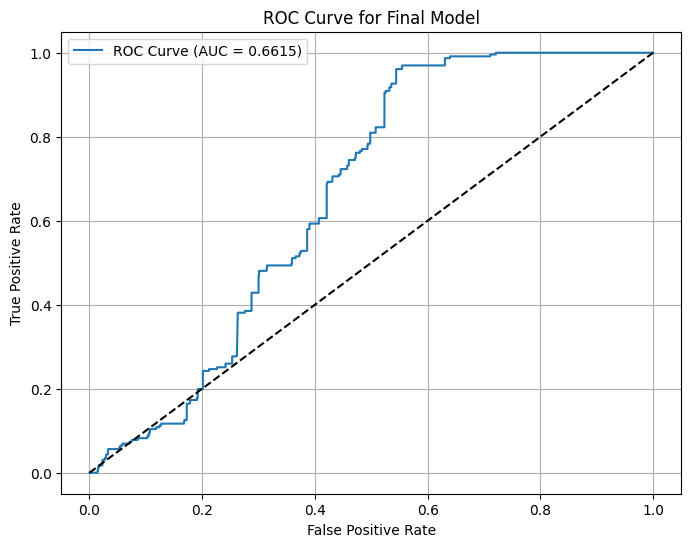

In [34]:

best_model = best_xgb_model

# prediction
y_pred = best_model.predict(X_test_final)
y_prob = best_model.predict_proba(X_test_final)[:, 1]

# Evaluation metrics
print("Final Model Performance on Testing Dataset")


accuracy = accuracy_score(y_test_final, y_pred)
precision = precision_score(y_test_final, y_pred)
recall = recall_score(y_test_final, y_pred)
f1 = f1_score(y_test_final, y_pred)
roc_auc = roc_auc_score(y_test_final, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# ------ CLASSIFICATION REPORT AND CONFUSION MATRIX ------ #
print("\nClassification Report:")
print(classification_report(y_test_final, y_pred))

cm = confusion_matrix(y_test_final, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Flare", "Flare"], yticklabels=["No Flare", "Flare"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC Curve for the final model
fpr, tpr, _ = roc_curve(y_test_final, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Final Model")
plt.legend()
plt.grid(True)
plt.show()